In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4094,ham,I ain't answerin no phone at what is actually ...,NaN,NaN,NaN
2267,ham,Finish liao... U?,NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
# Line of Action

# Data Cleaning
# EDA
# Feature Engineering
# Text Preprocessing
# Model Building
# Evaluation
# Improvement


In [5]:
#1 Data Cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# Since very few non null values is present in the last three columns it is dropped as of no use.

df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'],inplace = True)
df.sample(5)

,v1,v2
3056,ham,Just woke up. Yeesh its late. But I didn't fal...
3432,ham,Christmas is An occasion that is Celebrated as...
1650,ham,I dont have any of your file in my bag..i was ...
286,ham,Ok..
919,ham,Dont talk to him ever ok its my word.


In [7]:
# Renaming the Columns

df.rename(columns={'v1':'target','v2':'text'},inplace = True)
df.sample(5)

,target,text
4251,ham,"Send ur birthdate with month and year, I will ..."
5440,ham,Thank you. do you generally date the brothas?
809,ham,Ugh I don't wanna get out of bed. It's so warm.
3441,spam,Save money on wedding lingerie at www.bridal.p...
396,ham,Was actually sleeping and still might when u c...


In [8]:
# Turning the target column into classes

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [9]:
df['target'] = encoder.fit_transform(df['target'])
df.sample(2)

,target,text
4087,0,He needs to stop going to bed and make with th...
3257,0,He fucking chickened out. He messaged me he wo...


In [10]:
df.isnull().sum()

,0
target,0
text,0


In [11]:
#checking of the Duplicate value

df.duplicated().sum()

np.int64(403)

In [12]:
#Dropping the Duplicate Value

df.drop_duplicates(keep = 'first',inplace = True)

In [13]:
df.shape

(5169, 2)

In [14]:
# 2. EDA

In [15]:
# Checking the Percentage of Spam and Non-Spam
p_not_spam = df[df['target'] == 0].shape[0]/df['target'].shape[0] *100
print('Percentage of not Spam is :',p_not_spam)
print('Percentage of Spam is :',(100 - p_not_spam))

Percentage of not Spam is : 87.3669955503966
Percentage of Spam is : 12.633004449603405


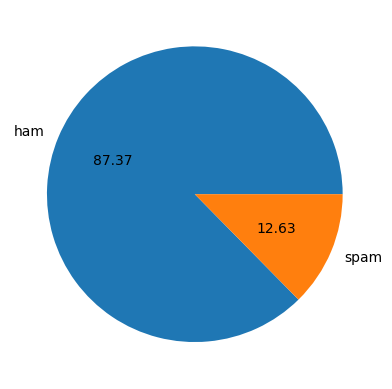

In [16]:
plt.pie(df['target'].value_counts(), labels = ['ham','spam'], autopct ="%0.2f")
plt.show()

In [17]:
pip install nltk

In [39]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [19]:
# Number of Characters in each message count

df['num_character'] = df['text'].apply(len)
df.sample(2)

,target,text,num_character
5151,0,No problem with the renewal. I.ll do it right ...,79
3204,0,"Oh, yes, I've just been a little under the wea...",90


In [20]:
# Number of Words in each message count

df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))
df.sample(2)

,target,text,num_character,num_words
353,0,Yo you guys ever figure out how much we need f...,129,29
1427,0,THING R GOOD THANX GOT EXAMS IN MARCH IVE DONE...,126,29


In [21]:
# No of sentence in each message count

df['num_sent'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.sample(2)

,target,text,num_character,num_words,num_sent
3999,1,This is the 2nd time we have tried to contact ...,159,34,4
2677,0,Where in abj are you serving. Are you staying ...,64,15,2


In [22]:
# Complete Overview of all messages character count, Sentence Count,sentence count
df[['num_character','num_words','num_sent']].describe()


,num_character,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [23]:
# no of ham messages overview

df[df['target'] == 0][['num_character','num_words','num_sent']].describe()

,num_character,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
# no of spam messages overview

df[df['target'] == 1][['num_character','num_words','num_sent']].describe()

,num_character,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_character', ylabel='Count'>

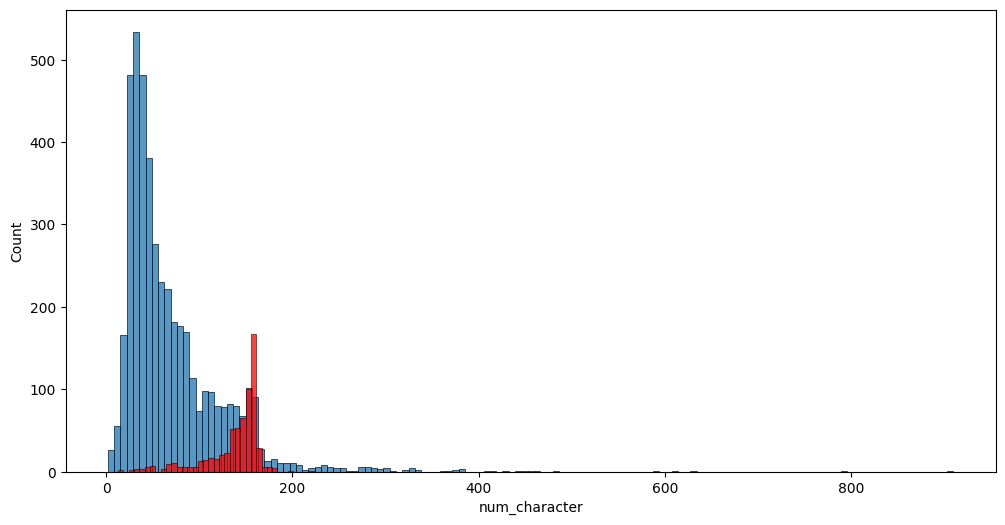

In [25]:
# We can observe that the spam messages is larger as compared to the not spam messages
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'],color='red')

<Axes: xlabel='num_sent', ylabel='Count'>

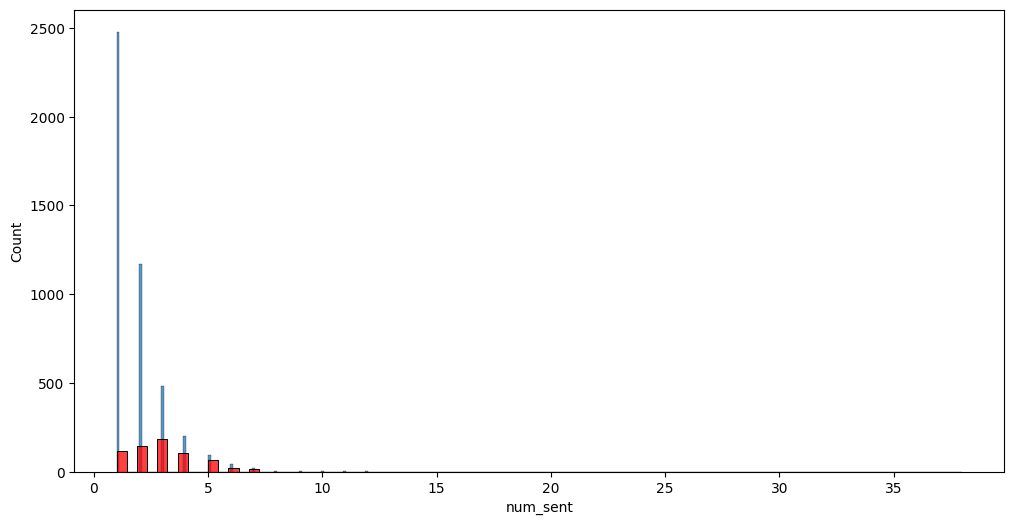

In [26]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_sent'])
sns.histplot(df[df['target'] == 1]['num_sent'],color='red')

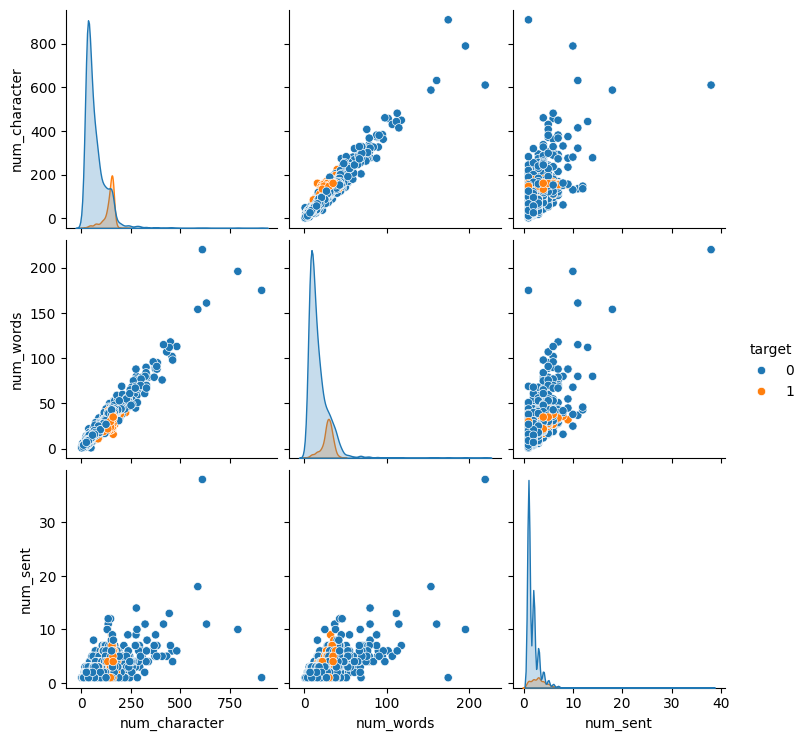

In [27]:
sns.pairplot(df,hue='target')

<Axes: >

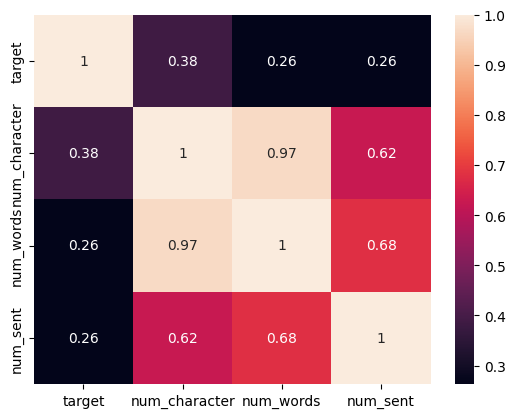

In [28]:
sns.heatmap(df[['target','num_character','num_words','num_sent']].corr(),annot=True)

In [29]:
#3. Data Preprocessing
# a. Lower case
# b. Tokenisation
# c. Remove special characters
# d. Remove stop words and Punctuation
# e. Stemming

In [41]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')
import string
string.punctuation

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [45]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [48]:
def trans_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [49]:
trans_text(df['text'][1])

'ok lar joke wif u oni'

In [51]:
df['transformed_text'] = df['text'].apply(trans_text)

In [53]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')


In [56]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))

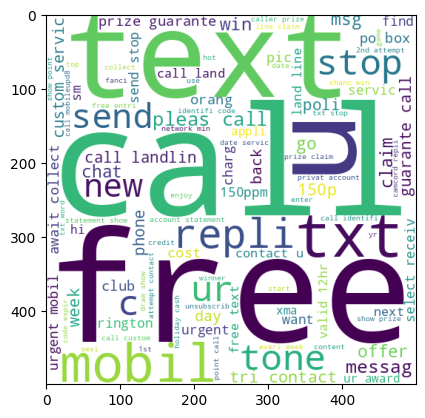

In [57]:
plt.imshow(spam_wc)

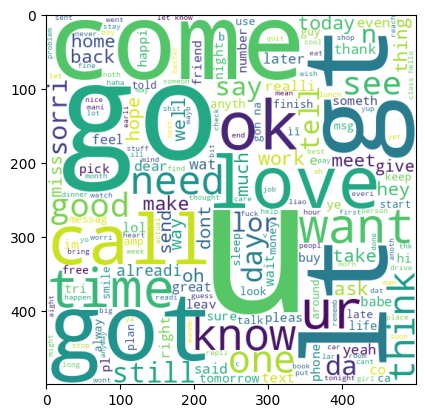

In [58]:
not_spam = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.imshow(not_spam)

In [59]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

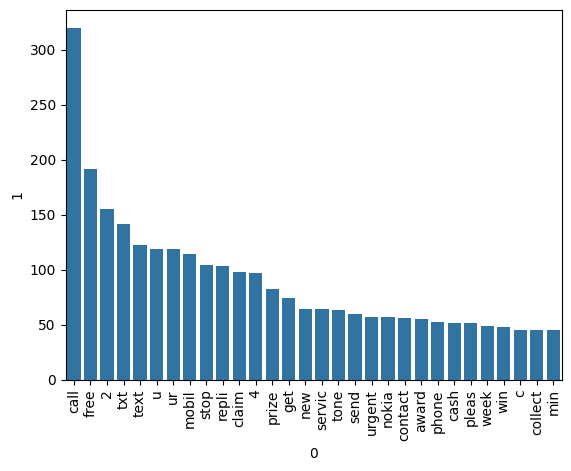

In [61]:
from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

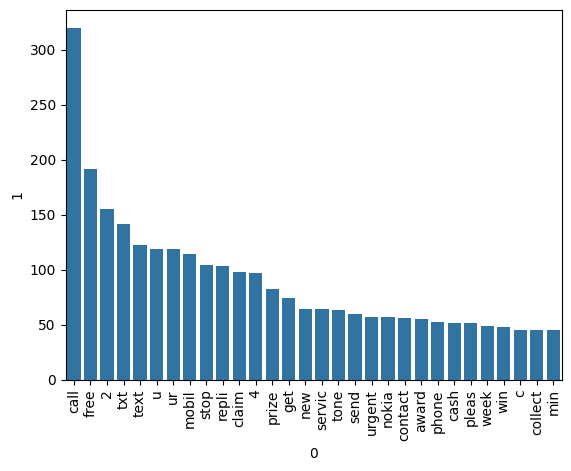

In [62]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [63]:
# Model Building

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [67]:
x = cv.fit_transform(df['transformed_text']).toarray()

In [68]:
x.shape

(5169, 6708)

In [69]:
y = df['target'].values

In [70]:
y

array([0, 0, 1, ..., 0, 0, 0])